<a href="https://colab.research.google.com/github/maria-antonia-analytics/data-analysis-portfolio/blob/main/03-python-system-log-analysis/notebooks/system_log_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# System Log & Performance Analysis

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/maria-antonia-analytics/data-analysis-portfolio/blob/main/03-python-system-log-analysis/notebooks/system_log_analysis.ipynb)

**Goal:** use Python to turn nine months of raw server logs into answers an IT operations team can act on.

**Data:** two real logs from the same Linux server (hostname `combo`), 9 June 2005 to 28 February 2006, from the public [Loghub](https://github.com/logpai/loghub) collection:

- `Linux.log`: the system log (kernel, SSH, FTP, scheduled jobs)
- `Apache.log`: the web server's error log

The raw files were parsed into tables by `src/parse_logs.py`. This notebook loads those tables and answers four questions:

1. Can the data be trusted? (data quality)
2. Was the server stable, and if not, what went wrong? (performance)
3. Who was trying to get in? (security)
4. What do the web server errors say? (web)

In [1]:
# Running in Google Colab? This cell downloads the project files first.
# On your own computer it does nothing.
import os
import subprocess
import sys

if "google.colab" in sys.modules and not os.path.exists("../data/clean"):
    subprocess.run(["git", "clone", "-q",
                    "https://github.com/maria-antonia-analytics/data-analysis-portfolio.git"], check=True)
    os.chdir("data-analysis-portfolio/03-python-system-log-analysis/notebooks")

In [2]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

DATA = Path("../data/clean")
IMAGES = Path("../images")
IMAGES.mkdir(exist_ok=True)

linux = pd.read_csv(DATA / "linux_events.csv", parse_dates=["timestamp"])
apache = pd.read_csv(DATA / "apache_events.csv", parse_dates=["timestamp"])

print(f"Linux events:  {len(linux):,} rows, {linux.shape[1]} columns")
print(f"Apache events: {len(apache):,} rows, {apache.shape[1]} columns")
linux.head(3)

Linux events:  25,549 rows, 10 columns
Apache events: 52,004 rows, 6 columns


,timestamp,component,pid,message,event_type,service,killed_process,remote_host,target_user,session_user
0,2005-06-09 06:06:20,syslogd 1.4.1,NaN,restart.,other,syslogd 1.4.1,NaN,NaN,NaN,NaN
1,2005-06-09 06:06:20,syslog,NaN,syslogd startup succeeded,other,syslog,NaN,NaN,NaN,NaN
2,2005-06-09 06:06:20,syslog,NaN,klogd startup succeeded,other,syslog,NaN,NaN,NaN,NaN


In [3]:
# One look for all charts: a fixed colour order, light grid, no chart junk.
BLUE, ORANGE, AQUA, YELLOW, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#c3c2b7"
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e1e0d9"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "axes.edgecolor": GREY, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.grid.axis": "y", "grid.color": GRID, "axes.axisbelow": True,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.labelcolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
    "font.size": 10, "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
})

## 1. Data quality

Before analysing anything, check what the parser kept, what it skipped, and whether there are holes in the timeline.

In [4]:
pd.read_csv(DATA / "parse_report.csv")

,log,raw_lines,parsed_rows,skipped_lines,first_event,last_event,skipped_pct
0,Linux.log,25567,25549,18,2005-06-09 06:06:17,2006-02-28 04:48:54,0.07
1,Apache.log,56482,52004,4478,2005-06-09 06:07:04,2006-02-28 03:49:01,7.93


In [5]:
# Days with no log lines at all
linux_daily = linux.set_index("timestamp").resample("D").size()
apache_daily = apache.set_index("timestamp").resample("D").size()

print(f"Period covered: {len(linux_daily)} days")
print(f"Days with no syslog lines:  {(linux_daily == 0).sum()}  ->", [str(d.date()) for d in linux_daily[linux_daily == 0].index])
print(f"Days with no Apache lines:  {(apache_daily == 0).sum()}")
print(f"Missing timestamps: {linux.timestamp.isna().sum()} (Linux), {apache.timestamp.isna().sum()} (Apache)")

Period covered: 265 days
Days with no syslog lines:  2  -> ['2006-02-04', '2006-02-21']
Days with no Apache lines:  35
Missing timestamps: 0 (Linux), 0 (Apache)


**What this tells us**

- The syslog parsed almost completely: only 18 of 25,567 lines (0.07%) were skipped. They are "last message repeated N times" notices with no component.
- The Apache log has 4,478 lines (7.9%) that contain only the text `script not found or unable to stat`, with no timestamp or client. They cannot be placed in time, so they are excluded.
- The syslog has no year. I set the start year to 2005 because the Apache log from the same server starts on the same day and minute (Thu 9 June 2005).
- The syslog is silent on 2 of 265 days. A day with no Apache lines only means no errors were logged, so it is not a gap.

## 2. What is in the system log?

In [6]:
labels = {
    "oom_kill": "Out-of-memory kill", "auth_failure": "Failed login", "ftp_connection": "FTP connection",
    "kernel_other": "Other kernel message", "other": "Other service message",
    "unknown_user": "Login with unknown username", "session_opened": "Session opened",
    "session_closed": "Session closed", "logrotate_failure": "Log rotation failed", "boot": "Server boot",
}
summary = linux.event_type.map(labels).value_counts().rename("events").to_frame()
summary["share_%"] = (summary.events / len(linux) * 100).round(1)
summary

,events,share_%
event_type,,
Out-of-memory kill,10404,40.7
Failed login,3990,15.6
FTP connection,3357,13.1
Other kernel message,3258,12.8
Other service message,2123,8.3
Login with unknown username,1056,4.1
Session closed,561,2.2
Session opened,561,2.2
Log rotation failed,231,0.9


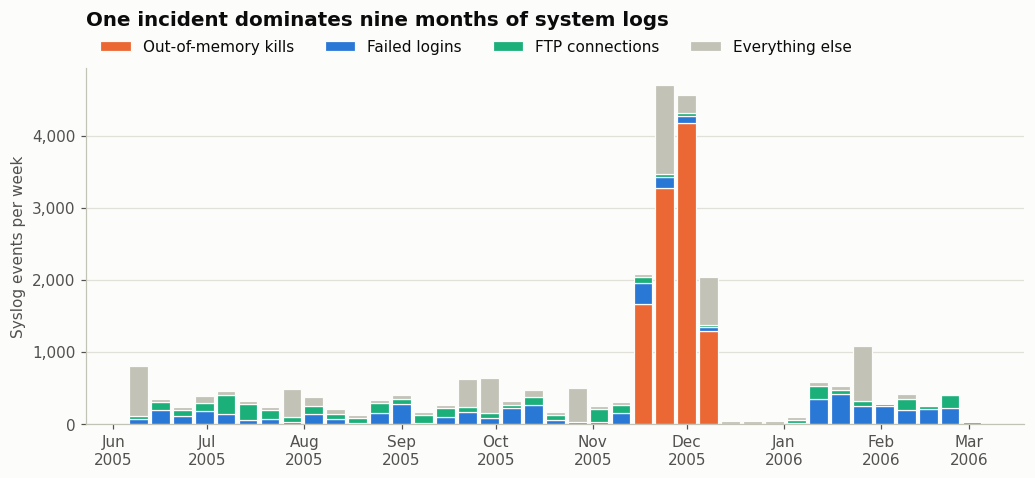

In [7]:
group = linux.event_type.map({
    "oom_kill": "Out-of-memory kills", "auth_failure": "Failed logins", "unknown_user": "Failed logins",
    "ftp_connection": "FTP connections"}).fillna("Everything else")
order = ["Out-of-memory kills", "Failed logins", "FTP connections", "Everything else"]
weekly = (linux.assign(group=group).groupby([pd.Grouper(key="timestamp", freq="W-MON", label="left", closed="left"), "group"])
          .size().unstack(fill_value=0)[order])

fig, ax = plt.subplots(figsize=(11, 4.2))
bottom = pd.Series(0, index=weekly.index)
for name, colour in zip(order, [ORANGE, BLUE, AQUA, GREY]):
    ax.bar(weekly.index, weekly[name], bottom=bottom, width=6, align="edge", color=colour,
           edgecolor="#fcfcfb", linewidth=0.8, label=name)
    bottom = bottom + weekly[name]
ax.set_title("One incident dominates nine months of system logs", pad=28)
ax.set_ylabel("Syslog events per week")
ax.xaxis.set_major_locator(mdates.MonthLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
ax.legend(frameon=False, ncols=4, loc="lower left", bbox_to_anchor=(0, 1.0))
fig.savefig(IMAGES / "01_weekly_events.png")
plt.show()

In [8]:
monthly = linux.set_index("timestamp").resample("MS").size()
normal = monthly[~monthly.index.isin(pd.to_datetime(["2005-11-01", "2005-12-01"]))]
print(monthly.rename(lambda d: d.strftime("%Y-%m")).to_string())
print(f"\nTypical month (excluding Nov and Dec): {normal.mean():,.0f} events")
print(f"November 2005: {monthly['2005-11-01']:,} events = {monthly['2005-11-01'] / normal.mean():.1f}x a typical month")

timestamp
2005-06    1605
2005-07    1659
2005-08    1208
2005-09    1827
2005-10    1538
2005-11    9304
2005-12    4748
2006-01    2438
2006-02    1222

Typical month (excluding Nov and Dec): 1,642 events
November 2005: 9,304 events = 5.7x a typical month


A typical month produces about 1,600 syslog events. November 2005 produced 9,304, almost six times as many, and nearly all of the extra volume is one event type: the kernel killing processes because the server ran out of memory.

## 3. Performance: the out-of-memory incident

When Linux has no memory left, the kernel picks a process and kills it ("OOM kill"). Each kill is logged as `Out of Memory: Killed process <pid> (<name>)`.

In [9]:
oom = linux[linux.event_type == "oom_kill"]
oom_daily = oom.set_index("timestamp").resample("D").size()
oom_days = oom_daily[oom_daily > 0]

print(f"OOM kills in total:      {len(oom):,} ({len(oom) / len(linux):.1%} of all syslog events)")
print(f"First kill:              {oom.timestamp.min()}")
print(f"Last kill:               {oom.timestamp.max()}")
print(f"Days with kills:         {len(oom_days)}")
print(f"Worst day:               {oom_days.idxmax().date()} with {oom_days.max():,} kills ({oom_days.max() / 24:.0f} per hour)")
print(f"Kills outside this window: {len(oom[(oom.timestamp < '2005-11-15') | (oom.timestamp >= '2005-12-10')])}")

OOM kills in total:      10,404 (40.7% of all syslog events)
First kill:              2005-11-15 04:30:29
Last kill:               2005-12-09 04:58:54
Days with kills:         24
Worst day:               2005-11-21 with 1,750 kills (73 per hour)
Kills outside this window: 0


In [10]:
killed = oom.killed_process.value_counts()
top = killed.head(4).copy()
top["all others"] = killed.iloc[4:].sum()
share = (top / len(oom) * 100).round(1)
pd.DataFrame({"kills": top, "share_%": share})

,kills,share_%
killed_process,,
httpd,8903,85.6
python,1153,11.1
sendmail,230,2.2
mrtg,50,0.5
all others,68,0.7


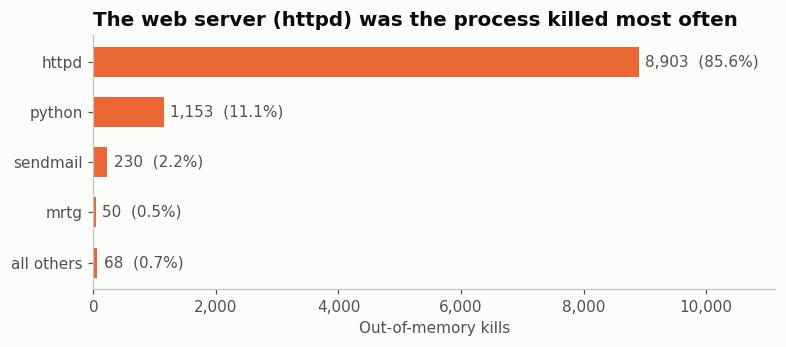

In [11]:
fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.barh(top.index[::-1], top.values[::-1], color=ORANGE, height=0.6)
ax.bar_label(bars, labels=[f"{v:,}  ({s:.1f}%)" for v, s in zip(top.values[::-1], share.values[::-1])], padding=4, color=MUTED)
ax.set_title("The web server (httpd) was the process killed most often")
ax.set_xlabel("Out-of-memory kills"); ax.grid(False); ax.set_xlim(0, top.max() * 1.25)
ax.xaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
fig.savefig(IMAGES / "02_killed_processes.png")
plt.show()

### Did users feel it? Linking the system log to the web server log

The Apache log records `mod_jk child workerEnv in error state` when a web server worker cannot do its job. If the memory problem really hurt the website, these errors should rise and fall with the kills.

In [12]:
jk = apache[apache.event_type == "jk_error_state"]
both = pd.DataFrame({
    "oom_kills": oom_daily,
    "web_worker_errors": jk.set_index("timestamp").resample("D").size(),
}).reindex(linux_daily.index).fillna(0)

incident = both["2005-11-15":"2005-12-09"]
print(f"Web worker errors, whole period:   {len(jk):,}")
print(f"  during the incident (25 days):   {incident.web_worker_errors.sum():,.0f} ({incident.web_worker_errors.sum() / len(jk):.0%})")
print(f"  per day during the incident:     {incident.web_worker_errors.mean():.0f}")
outside = both.drop(incident.index)
print(f"  per day outside the incident:    {outside.web_worker_errors.mean():.1f}")
print(f"Daily correlation between kills and web worker errors: r = {both.oom_kills.corr(both.web_worker_errors):.2f}")

Web worker errors, whole period:   4,349
  during the incident (25 days):   4,172 (96%)
  per day during the incident:     167
  per day outside the incident:    0.7
Daily correlation between kills and web worker errors: r = 0.97


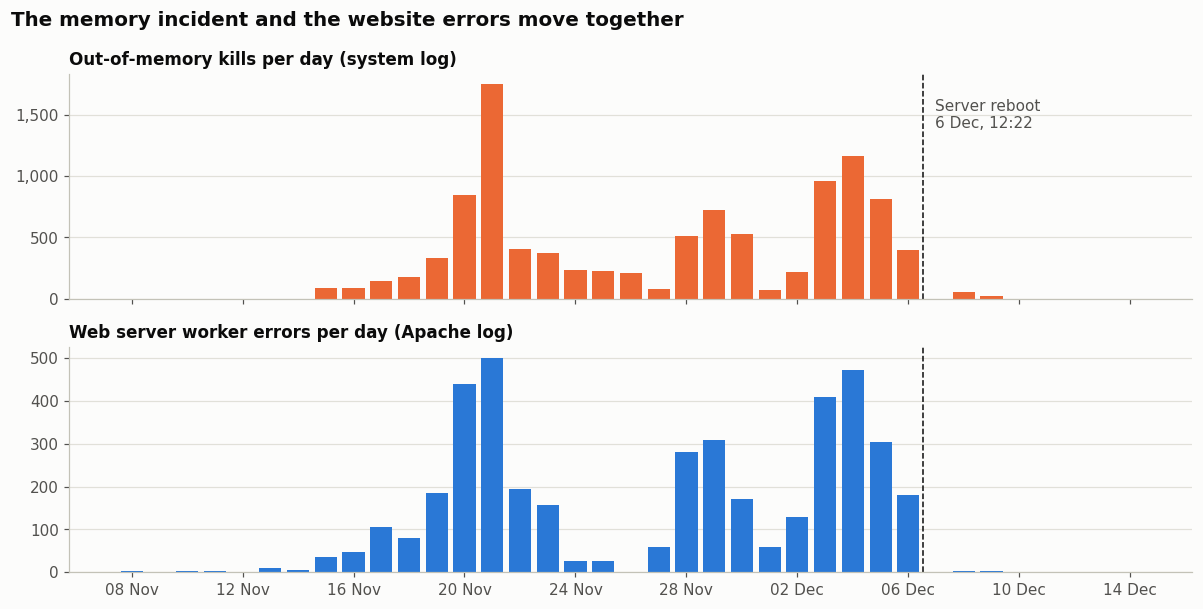

In [13]:
boots = linux.loc[linux.event_type == "boot", "timestamp"]
window = both["2005-11-08":"2005-12-14"]

fig, axes = plt.subplots(2, 1, figsize=(11, 5.6), sharex=True)
for ax, col, colour, title in zip(
        axes, ["oom_kills", "web_worker_errors"], [ORANGE, BLUE],
        ["Out-of-memory kills per day (system log)", "Web server worker errors per day (Apache log)"]):
    ax.bar(window.index, window[col], width=0.8, color=colour)
    ax.set_title(title, fontsize=11)
    ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
    for b in boots[(boots >= "2005-11-08") & (boots <= "2005-12-14")]:
        ax.axvline(b, color=INK, linewidth=1, linestyle="--")
axes[0].annotate("Server reboot\n6 Dec, 12:22", xy=(pd.Timestamp("2005-12-06 12:22"), 1500),
                 xytext=(8, 0), textcoords="offset points", color=MUTED, va="center")
axes[1].xaxis.set_major_locator(mdates.DayLocator(interval=4))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
fig.suptitle("The memory incident and the website errors move together", x=0.01, ha="left", fontweight="bold", fontsize=13)
fig.tight_layout()
fig.savefig(IMAGES / "03_oom_incident.png")
plt.show()

In [14]:
print("Server boots in the log:")
print(boots.dt.strftime("%Y-%m-%d %H:%M").to_string(index=False))
after = oom[oom.timestamp > "2005-12-06 12:22:57"]
print(f"\nOOM kills after the 6 Dec reboot: {len(after)} (last one on {after.timestamp.max().date()})")
print(f"OOM kills in the 3 days before it: {len(oom[(oom.timestamp >= '2005-12-03 12:22:57') & (oom.timestamp <= '2005-12-06 12:22:57')]):,}")

Server boots in the log:
2005-06-09 06:06
2005-06-10 11:31
2005-07-27 14:41
2005-09-19 05:57
2005-09-28 09:10
2005-10-25 10:08
2005-12-06 12:22
2006-01-26 12:22

OOM kills after the 6 Dec reboot: 75 (last one on 2005-12-09)
OOM kills in the 3 days before it: 2,913


**What this tells us**

- The incident ran from 15 November to 9 December 2005 (25 days, with kills on 24 of them) and produced 10,404 kills. Outside that window there are none.
- It grew for a week before peaking on 21 November at 1,750 kills in one day, about 73 an hour. A daily alert on this log line would have caught it on day one, when it was at 88 kills.
- 85.6% of the kills hit `httpd`, the web server, followed by `python` (11.1%). The log does not show which process was actually using the memory, only which ones were killed.
- The website was affected. 96% of all web worker errors in nine months fall inside the incident window, and the daily counts track the kills closely (r = 0.97).
- There was no reboot for the first three weeks. After the reboot on 6 December the kills fell from 2,913 in the previous three days to 75 in the following three, and stopped on 9 December. The log does not say what was changed, so the reboot may not be the only fix.

## 4. Security: who was trying to get in?

Failed logins are logged as `authentication failure`. Almost all of them come through SSH.

In [15]:
fails = linux[linux.event_type == "auth_failure"]
ssh = fails[fails.service == "sshd"]

print("Failed logins by service:")
print(fails.service.value_counts().to_string())
print(f"\nSSH failed logins: {len(ssh):,} from {ssh.remote_host.nunique()} different hosts")
ssh_daily = ssh.set_index("timestamp").resample("D").size().reindex(linux_daily.index, fill_value=0)
print(f"Days with at least one SSH failure: {(ssh_daily > 0).sum()} of {len(ssh_daily)} ({(ssh_daily > 0).mean():.0%})")
print(f"Busiest day: {ssh_daily.idxmax().date()} with {ssh_daily.max()} failures")

Failed logins by service:
service
sshd       3934
klogind      50
login         3
passwd        2
gdm           1

SSH failed logins: 3,934 from 345 different hosts
Days with at least one SSH failure: 177 of 265 (67%)
Busiest day: 2006-01-23 with 146 failures


In [16]:
users = ssh.target_user.fillna("(username not in the system)").value_counts()
users_table = pd.DataFrame({"failed_logins": users, "share_%": (users / len(ssh) * 100).round(1)})
users_table.head(8)

,failed_logins,share_%
target_user,,
root,2256,57.3
(username not in the system),1041,26.5
test,410,10.4
nobody,96,2.4
fax,29,0.7
amanda,26,0.7
guest,23,0.6
ftp,21,0.5


In [17]:
hosts = ssh.remote_host.value_counts()
print(f"Hosts with 20 or more failed attempts: {(hosts >= 20).sum()} of {len(hosts)}")
print(f"They account for {hosts[hosts >= 20].sum() / len(ssh):.0%} of all SSH failures")
print(f"Median attempts per host: {hosts.median():.0f}")
hosts.head(10).rename("failed_logins").to_frame()

Hosts with 20 or more failed attempts: 42 of 345
They account for 39% of all SSH failures
Median attempts per host: 10


,failed_logins
remote_host,
219.150.28.34,85
219.72.254.36,83
65.168.94.4,81
220.82.197.48,80
150.183.249.110,80
210.109.97.31,70
pc180-233.nttu.edu.tw,67
85.17.1.3,64
212-41-230-229.hebragasse.xdsl-line.inode.at,59


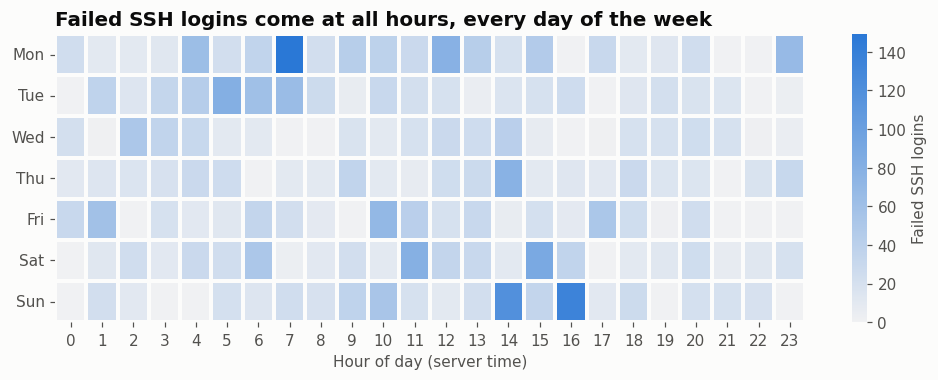

Share of failures outside Mon-Fri 09:00-17:59: 72%


In [18]:
days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
heat = (ssh.assign(day=ssh.timestamp.dt.dayofweek, hour=ssh.timestamp.dt.hour)
        .pivot_table(index="day", columns="hour", values="message", aggfunc="count", fill_value=0)
        .reindex(index=range(7), columns=range(24), fill_value=0))
heat.index = days

fig, ax = plt.subplots(figsize=(11, 3.4))
sns.heatmap(heat, cmap=sns.light_palette(BLUE, as_cmap=True), linewidths=1.5, linecolor="#fcfcfb",
            cbar_kws={"label": "Failed SSH logins"}, ax=ax)
ax.set_title("Failed SSH logins come at all hours, every day of the week")
ax.set_xlabel("Hour of day (server time)"); ax.set_ylabel(""); ax.tick_params(axis="y", rotation=0)
fig.savefig(IMAGES / "04_ssh_failures_heatmap.png")
plt.show()

office = ssh[(ssh.timestamp.dt.dayofweek < 5) & ssh.timestamp.dt.hour.between(9, 17)]
print(f"Share of failures outside Mon-Fri 09:00-17:59: {1 - len(office) / len(ssh):.0%}")

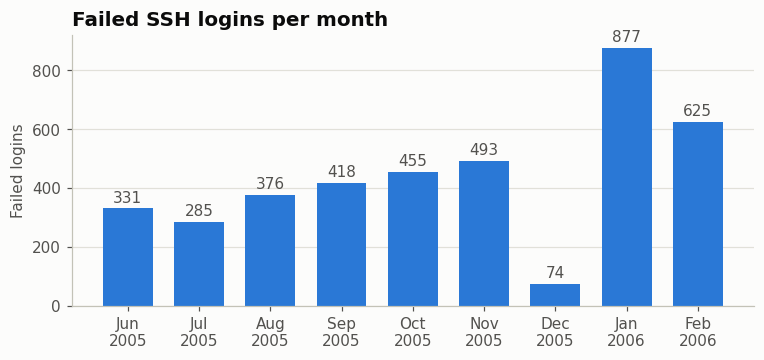

In [19]:
ssh_monthly = ssh.set_index("timestamp").resample("MS").size()
fig, ax = plt.subplots(figsize=(8, 3.2))
bars = ax.bar(ssh_monthly.index.strftime("%b\n%Y"), ssh_monthly.values, color=BLUE, width=0.7)
ax.bar_label(bars, padding=2, color=MUTED)
ax.set_title("Failed SSH logins per month"); ax.set_ylabel("Failed logins")
fig.savefig(IMAGES / "05_ssh_failures_monthly.png")
plt.show()

### Successful SSH logins

The log does not record where a successful session came from, so I can only count them and check whether any followed a failed attempt on the same account.

In [20]:
opened = linux[(linux.event_type == "session_opened") & (linux.service == "sshd")]
print("Successful SSH sessions by account:")
print(opened.session_user.value_counts().to_string())

# For each successful session: failed attempts on the same account in the 10 minutes before it
def failures_before(row, minutes=10):
    start = row.timestamp - pd.Timedelta(minutes=minutes)
    same = ssh[(ssh.target_user == row.session_user) & (ssh.timestamp >= start) & (ssh.timestamp <= row.timestamp)]
    return len(same)

opened = opened.assign(failures_10min_before=opened.apply(failures_before, axis=1))
flagged = opened[opened.failures_10min_before > 0]
print(f"\nSessions opened within 10 minutes of a failed attempt on the same account: {len(flagged)} of {len(opened)}")
flagged.groupby("session_user").agg(sessions=("timestamp", "size"), first=("timestamp", "min"), last=("timestamp", "max"))

Successful SSH sessions by account:
session_user
test    67
root    15

Sessions opened within 10 minutes of a failed attempt on the same account: 12 of 82


,sessions,first,last
session_user,,,
root,1,2005-08-30 11:38:28,2005-08-30 11:38:28
test,11,2005-10-07 18:55:53,2005-10-12 01:46:33


In [21]:
# When was the "test" account used, and who was failing to log in to it just before?
test_sessions = opened[opened.session_user == "test"]
print("Successful 'test' sessions by day:")
print(test_sessions.timestamp.dt.date.value_counts().sort_index().to_string())
print(f"\nShare opened between 00:00 and 05:59: {(test_sessions.timestamp.dt.hour < 6).mean():.0%}")

october = ssh[(ssh.target_user == "test") & (ssh.timestamp >= "2005-10-07") & (ssh.timestamp < "2005-10-13")]
near = pd.concat([october[(october.timestamp >= t - pd.Timedelta(minutes=10)) & (october.timestamp <= t)]
                  for t in flagged[flagged.session_user == "test"].timestamp]).drop_duplicates()
print(f"Hosts behind the failed attempts just before those sessions: {near.remote_host.nunique()}")
print(near.remote_host.value_counts().to_string())

Successful 'test' sessions by day:
timestamp
2005-06-12     1
2005-06-17     1
2005-06-30    10
2005-07-01     8
2005-07-02     8
2005-07-07     6
2005-07-13     3
2005-10-07     4
2005-10-08     2
2005-10-10     7
2005-10-11    12
2005-10-12     5

Share opened between 00:00 and 05:59: 52%
Hosts behind the failed attempts just before those sessions: 5
remote_host
bozesan.teleson.ro               7
squid.netcomputers.ro            1
81.196.56.79                     1
81.196.56.77                     1
88-213-181-81-cable.canals.ro    1


In [22]:
ftp = linux[linux.event_type == "ftp_connection"]
ftp_hosts = ftp.remote_host.value_counts()
ftp_daily = ftp.set_index("timestamp").resample("D").size()
print(f"FTP connections: {len(ftp):,} from {ftp.remote_host.nunique()} addresses")
print(f"Top 5 addresses: {ftp_hosts.head(5).sum():,} connections ({ftp_hosts.head(5).sum() / len(ftp):.0%})")
print(f"Busiest day: {ftp_daily.idxmax().date()} with {ftp_daily.max()} connections "
      f"(median active day: {ftp_daily[ftp_daily > 0].median():.0f})")
one_day = ftp[ftp.timestamp.dt.date == ftp_daily.idxmax().date()]
print(f"On that day {one_day.remote_host.value_counts().iloc[0]} connections came from one address within "
      f"{(one_day.timestamp.max() - one_day.timestamp.min()).total_seconds() / 60:.0f} minutes")

FTP connections: 3,357 from 134 addresses
Top 5 addresses: 630 connections (19%)
Busiest day: 2005-11-05 with 189 connections (median active day: 23)
On that day 189 connections came from one address within 5 minutes


**What this tells us**

- The server was under constant, automated password guessing: 3,934 failed SSH logins from 345 hosts, on two days out of three. 72% arrive outside weekday office hours, which fits bots, not staff who forgot a password.
- 57% of the attempts target `root`. A further 26% use usernames that do not exist on the server.
- The `test` account needs an investigation. It is the second most attacked real account (410 failures) and it also has 67 successful SSH sessions, 65 of them in two short bursts (30 June to 13 July and 7 to 12 October), and half of them between midnight and 06:00. In the October burst, 11 sessions opened within 10 minutes of a failed attempt on `test`, and those failed attempts came from five different outside hosts. That pattern is what a guessed password looks like. The log cannot confirm it, because it does not record where successful logins came from.
- FTP shows the same pattern: 3,357 connections, with bursts of up to 189 from one address in a few minutes.
- Attempts did not fall over time. January 2006 was the worst month (877).

## 5. Web server errors

In [23]:
web_labels = {"file_not_found": "File not found", "directory_forbidden": "Directory listing blocked",
              "script_not_found": "Script not found", "jk_error_state": "Worker in error state"}
errors = apache[apache.level == "error"].copy()
errors["type"] = errors.event_type.map(web_labels).fillna("Other error")
types = errors.type.value_counts()
print(f"Apache log lines by level:\n{apache.level.value_counts().to_string()}\n")
pd.DataFrame({"errors": types, "share_%": (types / len(errors) * 100).round(1)})

Apache log lines by level:
level
error     38081
notice    13755
warn        168



,errors,share_%
type,,
File not found,20861,54.8
Directory listing blocked,6745,17.7
Worker in error state,4349,11.4
Script not found,3301,8.7
Other error,2825,7.4


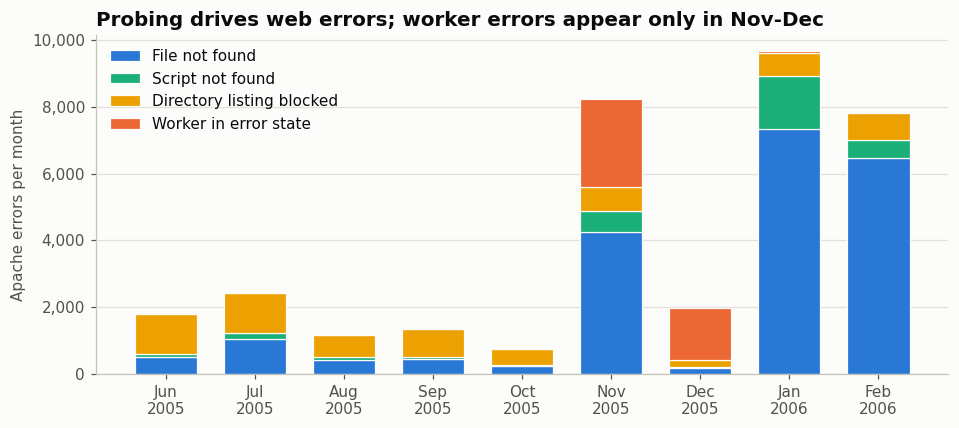

type,File not found,Script not found,Directory listing blocked,Worker in error state
timestamp,,,,
2005-06,502,89,1215,21
2005-07,1047,183,1207,14
2005-08,427,90,649,11
2005-09,433,86,822,13
2005-10,232,37,471,28
2005-11,4257,609,731,2639
2005-12,185,36,182,1560
2006-01,7327,1606,665,63
2006-02,6451,565,803,0


In [24]:
order = ["File not found", "Script not found", "Directory listing blocked", "Worker in error state"]
web_monthly = errors[errors.type.isin(order)].groupby([pd.Grouper(key="timestamp", freq="MS"), "type"]).size().unstack(fill_value=0)[order]

fig, ax = plt.subplots(figsize=(10, 4))
bottom = pd.Series(0, index=web_monthly.index)
x = web_monthly.index.strftime("%b\n%Y")
for name, colour in zip(order, [BLUE, AQUA, YELLOW, ORANGE]):
    ax.bar(x, web_monthly[name].values, bottom=bottom.values, color=colour, width=0.7,
           edgecolor="#fcfcfb", linewidth=0.8, label=name)
    bottom = bottom + web_monthly[name]
ax.set_title("Probing drives web errors; worker errors appear only in Nov-Dec")
ax.set_ylabel("Apache errors per month"); ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
ax.legend(frameon=False, loc="upper left")
fig.savefig(IMAGES / "06_web_errors_monthly.png")
plt.show()
web_monthly.rename(lambda d: d.strftime("%Y-%m"))

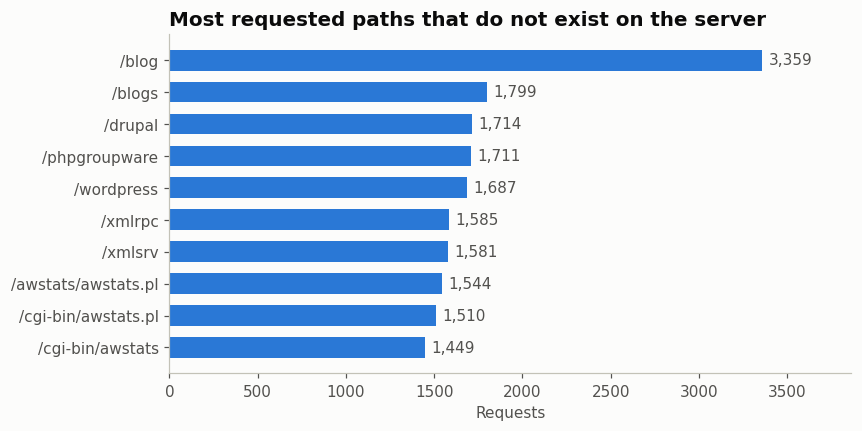

'Not found' errors: 24,162 across 107 different paths
Top 10 paths: 17,939 (74%)


In [25]:
missing = errors[errors.event_type.isin(["file_not_found", "script_not_found"])]
paths = missing.path.str.replace("/var/www/html/", "/", regex=False).str.replace("/var/www/cgi-bin/", "/cgi-bin/", regex=False)
top_paths = paths.value_counts().head(10)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(top_paths.index[::-1], top_paths.values[::-1], color=BLUE, height=0.65)
ax.bar_label(bars, labels=[f"{v:,}" for v in top_paths.values[::-1]], padding=4, color=MUTED)
ax.set_title("Most requested paths that do not exist on the server")
ax.set_xlabel("Requests"); ax.grid(False); ax.set_xlim(0, top_paths.max() * 1.15)
fig.savefig(IMAGES / "07_probed_paths.png")
plt.show()

print(f"'Not found' errors: {len(missing):,} across {paths.nunique():,} different paths")
print(f"Top 10 paths: {top_paths.sum():,} ({top_paths.sum() / len(missing):.0%})")

In [26]:
clients = errors.client_ip.value_counts()
late = missing[missing.timestamp >= "2006-01-01"]
print(f"Client addresses causing errors: {len(clients):,}")
print(f"Top 10 addresses: {clients.head(10).sum():,} errors ({clients.head(10).sum() / errors.client_ip.notna().sum():.0%} of errors with a client)")
print(f"'Not found' errors in Jan-Feb 2006: {len(late):,} ({len(late) / len(missing):.0%} of the nine-month total)")
per_ip = missing.groupby("client_ip").path.nunique()
print(f"Addresses that asked for 5 or more different missing paths: {(per_ip >= 5).sum():,} of {len(per_ip):,}")
clients.head(5).rename("errors").to_frame()

Client addresses causing errors: 4,695
Top 10 addresses: 4,103 errors (13% of errors with a client)
'Not found' errors in Jan-Feb 2006: 15,949 (66% of the nine-month total)
Addresses that asked for 5 or more different missing paths: 218 of 469


,errors
client_ip,
218.144.240.75,1002
210.245.233.251,624
211.99.203.228,440
80.55.121.106,322
61.152.90.96,315


**What this tells us**

- 63% of all Apache errors are requests for files or scripts that do not exist. The paths are the giveaway: `/blog`, `/drupal`, `/wordpress`, `/phpgroupware`, `/xmlrpc`, `/awstats`. These are common web applications, none of which is installed here. Scanners are checking whether a vulnerable copy exists.
- The probing came in waves. January and February 2006 alone hold 66% of the nine-month total, after an earlier wave in November 2005.
- A further 6,745 errors are blocked attempts to list the web root directory.
- The only error type that reflects a real fault on the server is "worker in error state", and it is concentrated in the memory incident.

## 6. Summary

| Area | Finding | Evidence |
|---|---|---|
| Performance | A 25-day memory incident went unnoticed for three weeks | 10,404 OOM kills, 15 Nov to 9 Dec 2005, peak 1,750 in one day |
| Performance | It took the website down with it | 85.6% of kills hit `httpd`; web worker errors track kills at r = 0.97 |
| Security | Constant automated password guessing over SSH | 3,934 failures from 345 hosts; 57% aimed at `root` |
| Security | The `test` account may have been compromised | 410 failed and 67 successful logins; 11 sessions opened minutes after failed attempts |
| Web | Most web errors are scanners, not broken pages | 63% of errors are requests for software that is not installed |
| Data quality | Logs are usable but not perfect | 7.9% of Apache lines have no timestamp; syslog has no year |

### Recommendations

1. **Alert on the first OOM kill.** One line in the syslog would have flagged the incident on 15 November at 88 kills, six days before the peak.
2. **Monitor memory, not only logs.** Track memory and swap usage per process so the cause is known, and set memory limits on the web server's worker processes.
3. **Harden SSH.** Disable direct `root` login and password authentication (use keys), and block addresses after repeated failures with a tool such as fail2ban.
4. **Lock the `test` account and investigate it.** Review what its 67 sessions did, starting with 7 to 12 October 2005.
5. **Turn off FTP and telnet** if they are not needed. Both send passwords unencrypted and both attract automated connections.
6. **Filter scanner traffic** at the web server or firewall so real errors are not buried under probe noise.
7. **Fix the logging itself.** Add the year to syslog timestamps and investigate the `logrotate` failure, which was logged on 231 of the 265 days, at about 04:00.